# After a big one-day fall in NIFTY 50, does the market recover?
**AlgoChowk Quant Engineer assignment - one research investigation**

Flow: *Hypothesis -> Method -> Evidence -> Baseline -> Robustness -> Out-of-sample -> Falsification -> Backtest -> Conclusion*

**How to run**
1. `pip install -r requirements.txt`, then *Run All*. Every parameter lives in `config.yaml` - nothing in the engine is hard-coded.
2. No internet / Yahoo blocked? Put a NIFTY 50 CSV (`Date,Open,High,Low,Close`) in `data/raw/` and set `csv_path` in `config.yaml`.
3. **Out-of-sample discipline:** sections 1-4 and 6 use only data **before `split_date`**. The unseen period is touched *once*, in section 5, by flipping `RUN_OOS = True` after the parameters are frozen. Do not tune anything after you have seen it.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:                       # plain-python fallback
    display = print

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from niftyresearch import Config
from niftyresearch.data import prepare_data
from niftyresearch.events import add_features
from niftyresearch.research import (run_research, run_oos, research_end, robustness_grid, robustness_variants,
                                    by_year, by_vol_regime, compare_periods, falsification_scorecard, evaluate)
from niftyresearch.backtest import EventDrivenBacktester
from niftyresearch.plots import (plot_return_distributions, plot_event_paths, plot_grid_heatmap, plot_equity)
from niftyresearch.synthetic import make_synthetic_nifty

pd.options.display.float_format = "{:,.5f}".format
pd.options.display.width = 200
pd.options.display.max_columns = 40
plt.rcParams["figure.dpi"] = 110

cfg = Config.from_yaml(ROOT / "config.yaml")
USE_SYNTHETIC = False   # True = offline smoke test on FAKE data (never report those numbers)
RUN_OOS = True        # flip to True ONCE, after parameters are frozen (section 5)
print(cfg)

Config(ticker='^NSEI', data_start='2007-09-17', data_end=None, csv_path=None, cache_path='data/raw/nifty50_daily.csv', event_mode='fixed', threshold=-0.02, z_threshold=-2.0, percentile=0.02, vol_window=60, entry='next_open', holding_days=5, decluster=True, min_gap_days=None, holding_grid=(1, 2, 3, 5, 10, 20), threshold_grid=(-0.01, -0.015, -0.02, -0.025, -0.03, -0.04), crisis_windows=(('2008-09-01', '2009-06-30'), ('2020-02-15', '2020-06-30')), commission_bps=2.0, slippage_bps=3.0, split_date='2018-01-01', alpha=0.05, n_boot=10000, n_placebo=10000, seed=42, min_events=30, initial_capital=1000000)


## 1. Research design (the pre-registration)

**Hypothesis H1.** After a NIFTY 50 close-to-close fall of at least **2 %**, a long position entered at the **next session's open** and held for **5 trading days** earns a **positive net return that is larger than the return of an equally-timed position opened on an ordinary day**.
**H0.** The mean forward return after such falls is no better than the market's normal drift.

| Item | Definition | Why |
|---|---|---|
| Significant fall | close-to-close return <= **-2 %** (fixed). Robustness: vol-adjusted (`return / trailing 60d vol <= -2`) and an expanding-percentile version | 2 % is rare enough to be an "event" but frequent enough for a usable sample; a fixed level is easy to reproduce, the vol-adjusted version guards against volatility regimes |
| Recovery (primary) | net forward return **> 0** *and* **> baseline** | a positive return alone only reflects the market's upward drift |
| Recovery (secondary) | exit close >= the **pre-fall close** (full retracement of the drop) | descriptive: "did the fall get undone?" |
| Entry | **next session's open** (`entry: next_open`) | the fall is only known at the 15:30 close - the earliest realistic fill is the next open. Entering at the event-day close is kept only as an *optimistic* sensitivity |
| Exit / holding | close of day *t+h*, **h = 5** primary; 1-20 tested | ~1 trading week: long enough for a rebound, short enough to limit noise |
| Independence | events closer than *h* days are merged (first one kept) | overlapping windows share returns -> inflated significance |
| Costs | 5 bps per side (2 bps fees + 3 bps slippage) = **10 bps round trip**; stress at 20 and 40 bps | index futures / ETF proxy; slippage is larger in the volatile sessions that follow falls |
| Test period | research: data start -> 2017-12-31; out-of-sample: 2018-01-01 -> latest | chronological split, ~60/40, OOS contains a very different regime (COVID, 2022) |
| Baseline | *every* day's forward return with the **same entry/exit rule**, plus non-event days and high-volatility non-event days | separates "the fall matters" from "markets drift up" and from "volatile periods behave differently" |

**Key assumptions.** The index is tradable via futures/ETF at open/close prices; long-only, one position at a time, no leverage; cash earns 0 %; no dividends; daily bars only (no intraday path, so stops are not modelled).

## 2. Data: sourcing, validation, cleaning

In [2]:
if USE_SYNTHETIC:
    clean_df = make_synthetic_nifty()
    print("!! SYNTHETIC DATA - pipeline smoke test only !!")
else:
    d = prepare_data(cfg, root=ROOT)
    clean_df = d["clean"]
    print(d["provenance"])
    print("\nIntegrity checks on the RAW file:")
    display(d["report"].summary)
    print("Cleaning actions taken:")
    display(d["log"].head(30) if len(d["log"]) else "none needed")
    print(f"Suspicious observations FLAGGED (kept, not dropped): {len(d['flags'])}")
    display(d["flags"].head(30))
    print("Coverage - rows per year (NSE normally has ~245-250 sessions):")
    display(d["coverage"])

Source: cached download: data/raw/nifty50_daily.csv (originally Yahoo Finance ^NSEI)
Fields: Open, High, Low, Close (daily, unadjusted index levels)
Coverage: 2007-09-17 -> 2026-09-21  (4664 trading days after cleaning; 4664 raw rows)
Cleaning actions logged: 0   Flagged (kept) observations: 9

Integrity checks on the RAW file:


,check,rows_affected,action
0,unparseable_date,0,drop row
1,duplicate_date,0,keep last occurrence
2,out_of_order,0,sort ascending
3,missing_ohlc,0,drop row
4,non_positive_ohlc,0,drop row
5,high_low_inconsistent,0,clip High/Low to the O/C envelope (study only ...
6,flat_bar_O=H=L=C,0,drop row (stale / non-standard session)


Cleaning actions taken:


'none needed'

Suspicious observations FLAGGED (kept, not dropped): 9


,ret,open_gap,flags
Date,,,
2008-10-24,-0.12203,-0.00234,extreme_return(>10%)
2008-10-29,0.06848,0.06382,large_open_gap(>5%)
2009-05-18,0.17744,0.00041,extreme_return(>10%)
2014-10-07,-0.01172,-0.00606,calendar_gap(>5d)
2016-11-09,-0.01306,-0.05572,large_open_gap(>5%)
2020-03-13,0.03807,-0.05032,large_open_gap(>5%)
2020-03-23,-0.12980,-0.09145,"extreme_return(>10%), large_open_gap(>5%)"
2025-02-01,-0.00112,0.00086,weekend_session
2025-04-07,-0.03243,-0.05004,large_open_gap(>5%)


Coverage - rows per year (NSE normally has ~245-250 sessions):


,n_days,first,last,vs_expected,low_coverage
Date,,,,,
2007,72,2007-09-17,2007-12-31,-176,False
2008,245,2008-01-01,2008-12-31,-3,False
2009,241,2009-01-02,2009-12-31,-7,False
2010,250,2010-01-04,2010-12-31,2,False
2011,242,2011-01-03,2011-12-30,-6,False
2012,242,2012-01-03,2012-12-31,-6,False
2013,247,2013-01-02,2013-12-31,-1,False
2014,240,2014-01-02,2014-12-31,-8,False
2015,244,2015-01-02,2015-12-31,-4,False


**What to look at.** (i) Any year flagged `low_coverage` = missing sessions; (ii) `extreme_return` flags - the +17 % day of 2009-05-18 and the -13 % day of 2020-03-23 are *real* (circuit-limit / COVID) and are exactly the sort of events this study is about, so they are **kept**; (iii) flat `O=H=L=C` bars are dropped as stale / non-standard sessions; (iv) High/Low are only clipped, because the study uses Open and Close.

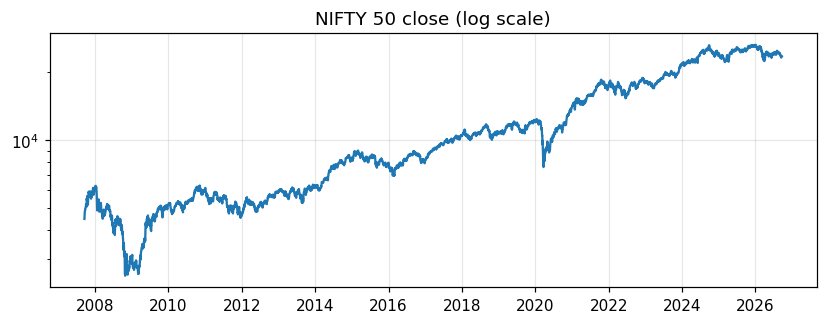

In [3]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogy(clean_df.index, clean_df["Close"]); ax.set_title("NIFTY 50 close (log scale)"); ax.grid(alpha=.3)
plt.show()

## 3. Event detection and forward returns (research sample only)

In [4]:
feat = add_features(clean_df, cfg)
END_R = research_end(feat, cfg)
print(f"Research sample : {feat.index[0].date()} -> {END_R.date()}")
print(f"Out-of-sample   : {cfg.split_date} -> {feat.index[-1].date()}   (NOT touched until section 5)\n")

exp = run_research(feat, cfg)
u = exp.universe
print(f"Event: close-to-close return <= {cfg.threshold:.1%} | entry: {cfg.entry} | hold: {cfg.holding_days} trading days")
print(f"Days in sample                : {len(u)}")
print(f"Qualifying events (raw)       : {len(exp.events_raw)}  ({len(exp.events_raw)/len(u):.2%} of days)")
print(f"Independent events (declustered): {len(exp.events)}")
crisis = pd.Series(False, index=exp.events_raw.index)
for a, b in cfg.crisis_windows:
    crisis |= (exp.events_raw.index >= a) & (exp.events_raw.index <= b)
print(f"Raw events inside GFC/COVID windows: {int(crisis.sum())} ({crisis.mean():.0%}) -> clustering is a real issue\n")
display(exp.event_table())

Research sample : 2007-09-17 -> 2017-12-29
Out-of-sample   : 2018-01-01 -> 2026-09-21   (NOT touched until section 5)

Event: close-to-close return <= -2.0% | entry: next_open | hold: 5 trading days
Days in sample                : 2510
Qualifying events (raw)       : 145  (5.78% of days)
Independent events (declustered): 92
Raw events inside GFC/COVID windows: 47 (32%) -> clustering is a real issue



,event_return,entry_date,entry_px,exit_date,exit_px,gross,net,retraced
event_date,,,,,,,,
2007-10-18,-0.03747,2007-10-19,"5,360.35010",2007-10-25,"5,568.95020",0.03892,0.03792,True
2007-11-20,-0.02146,2007-11-21,"5,778.79980",2007-11-27,"5,698.14990",-0.01396,-0.01496,False
2007-12-17,-0.04476,2007-12-18,"5,777.60010",2007-12-26,"6,070.75000",0.05074,0.04974,True
2008-01-15,-0.02136,2008-01-16,"6,065.00000",2008-01-22,"4,899.29980",-0.19220,-0.19320,False
2008-01-22,-0.05942,2008-01-23,"4,903.04980",2008-01-29,"5,280.79980",0.07704,0.07604,True
...,...,...,...,...,...,...,...,...
2016-01-07,-0.02231,2016-01-08,"7,611.64990",2016-01-14,"7,536.79980",-0.00983,-0.01083,False
2016-02-11,-0.03317,2016-02-12,"7,023.64990",2016-02-18,"7,191.75000",0.02393,0.02293,False
2016-04-05,-0.02005,2016-04-06,"7,636.04980",2016-04-12,"7,708.95020",0.00955,0.00855,False


## 4. Statistical evidence (research sample only)

,n,mean,median,std,win_rate,skew,excess_kurt,p05,p95,mean_net
"Events (all, may overlap)",145.00000,0.00267,0.00267,0.05478,0.51724,-0.05039,2.25663,-0.08457,0.09534,0.00167
Events (independent),92.00000,0.00070,0.00037,0.04726,0.50000,-0.44367,2.55033,-0.06775,0.08503,-0.00030
Baseline: all days,"2,510.00000",0.00131,0.00249,0.03273,0.54343,-0.00864,5.69076,-0.05051,0.04725,0.00031
Baseline: non-event days,"2,365.00000",0.00122,0.00247,0.03089,0.54503,-0.01135,5.54985,-0.04817,0.04487,0.00022
Baseline: high-vol non-event days,846.00000,0.00076,0.00312,0.04126,0.54610,-0.02101,3.66241,-0.06658,0.05758,-0.00024



Tests on the independent events:


,value
n_events_raw,145
n_events_independent,92
reliable(n>=min_events),True
mean_gross,0.00070
mean_net,-0.00030
baseline_mean_gross,0.00131
excess_mean_gross,-0.00061
cohens_d_vs_baseline,-0.01293
t_stat_net_vs_zero,-0.06173
p_net_gt_zero(one-sided t),0.52454


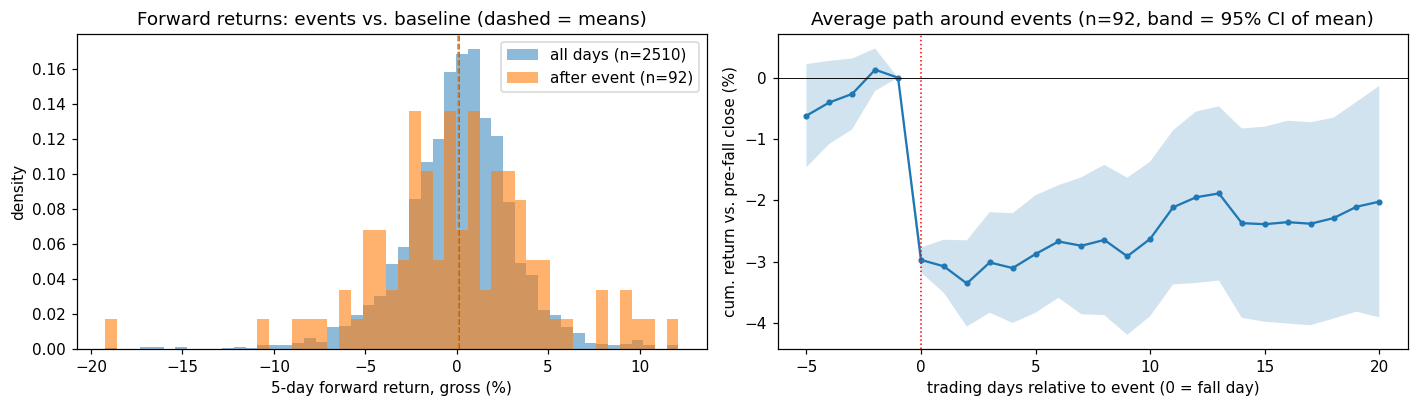

In [5]:
display(exp.summary_table()[["n","mean","median","std","win_rate","skew","excess_kurt","p05","p95","mean_net"]])
t = pd.Series(exp.tests)
print("\nTests on the independent events:")
display(t.to_frame("value"))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
plot_return_distributions(exp, ax[0]); plot_event_paths(feat, exp, ax=ax[1]); fig.tight_layout(); plt.show()

**Why each statistic / method.**
* **n (raw vs independent)** - the effective sample size. Everything else is only as good as this number.
* **Mean *and* median** - the mean is what a trader earns on average but is dragged by a few crash-rebound days; a big gap between them warns that the result is outlier-driven.
* **Win rate** - compared with the *baseline* win rate (about 53-55 % for any day); a 55 % win rate after falls says nothing.
* **Std / skew / kurtosis / 5-95 %** - returns after falls are more volatile: an edge must be judged per unit of risk (`mean_over_std`), not in isolation.
* **One-sided t-test vs baseline mean** - "is the mean higher than normal?" (directional hypothesis). Leans on the CLT, so it is *not* trusted alone.
* **Wilcoxon** - rank-based cross-check, robust to the fat tails.
* **Bootstrap CI of the excess return** - answers the more useful question *how big is the edge and how uncertain?* Baseline uses a **block** bootstrap because overlapping 5-day windows are autocorrelated.
* **Placebo test** - "how often would *n random days* (or n random *high-volatility* days) do this well?" - the most direct guard against confusing normal drift / volatile-regime behaviour with a fall effect.
* **Statistical != economic significance.** Compare `mean_net` (bps) with costs and with the CI's *lower* end; a "significant" 5 bps edge is untradable.

## 4b. Baseline and robustness (research sample only)

,threshold,h,n_raw,n,mean_gross,mean_net,median_net,win_rate_net,base_mean,excess,p_greater,p_holm,p_bh,reliable
0,-0.01000,1,422,422,-0.00081,-0.00181,-0.00175,0.43602,-0.00041,-0.00040,0.67049,1.00000,0.78489,True
1,-0.01000,2,422,340,0.00007,-0.00093,-0.00054,0.49118,0.00004,0.00004,0.49010,1.00000,0.78489,True
2,-0.01000,3,422,290,0.00126,0.00026,0.00266,0.53103,0.00047,0.00079,0.34671,1.00000,0.78489,True
3,-0.01000,5,422,222,0.00140,0.00040,0.00258,0.52252,0.00131,0.00009,0.48394,1.00000,0.78489,True
4,-0.01000,10,422,148,0.00174,0.00074,0.00324,0.52703,0.00328,-0.00154,0.64069,1.00000,0.78489,True
5,-0.01000,20,421,92,0.00827,0.00727,0.01266,0.58696,0.00710,0.00117,0.43905,1.00000,0.78489,True
6,-0.01500,1,245,245,-0.00105,-0.00205,-0.00223,0.42857,-0.00041,-0.00064,0.67771,1.00000,0.78489,True
7,-0.01500,2,245,206,-0.00018,-0.00118,-0.00204,0.46602,0.00004,-0.00022,0.54100,1.00000,0.78489,True
8,-0.01500,3,245,177,0.00116,0.00016,0.00299,0.52542,0.00047,0.00069,0.39996,1.00000,0.78489,True
9,-0.01500,5,245,146,0.00325,0.00225,0.00535,0.54795,0.00131,0.00195,0.26974,1.00000,0.78489,True



36 threshold x holding cells tried.  Nominal p<0.05: 0   |   Holm-adjusted: 0   |   BH-adjusted: 0


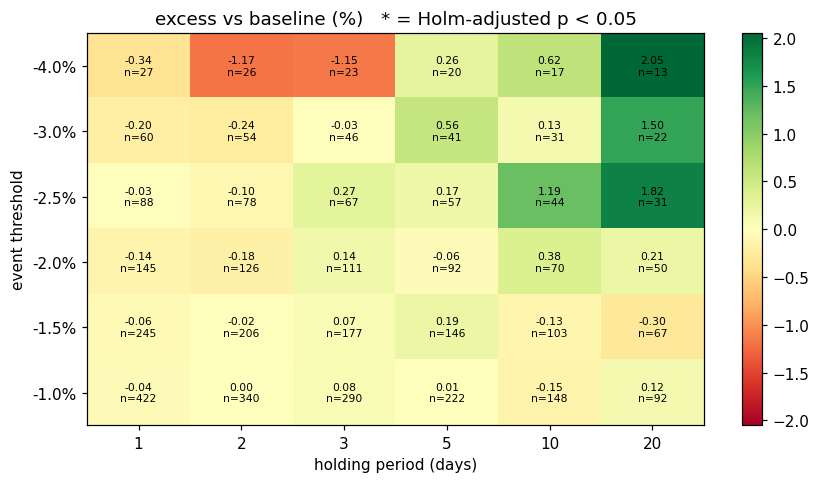

In [6]:
grid = robustness_grid(feat, cfg, end=END_R)
display(grid.round(5))
print(f"\n{len(grid)} threshold x holding cells tried.  Nominal p<{cfg.alpha}: {(grid.p_greater<cfg.alpha).sum()}   |   "
      f"Holm-adjusted: {(grid.p_holm<cfg.alpha).sum()}   |   BH-adjusted: {(grid.p_bh<cfg.alpha).sum()}")
fig, ax = plt.subplots(figsize=(8, 4.5)); plot_grid_heatmap(grid, ax=ax); fig.tight_layout(); plt.show()

In [7]:
var = robustness_variants(feat, cfg, end=END_R)
display(var)
print("\nBy calendar year (is it one or two episodes?):"); display(by_year(exp))
print("\nBy volatility regime (terciles of trailing vol):"); display(by_vol_regime(exp))

,n_raw,n,mean_gross,mean_net,median_net,win_rate_net,base_mean,excess,p_greater
variant,,,,,,,,,
Primary specification,145,92,0.00070,-0.00030,-0.00063,0.50000,0.00131,-0.00061,0.54920
No de-clustering (overlapping events),145,145,0.00267,0.00167,0.00167,0.51724,0.00131,0.00137,0.38205
Entry at event-day CLOSE (optimistic),145,92,0.00102,0.00002,0.00062,0.50000,0.00217,-0.00115,0.59074
Vol-adjusted event (z <= z_threshold),76,61,0.00722,0.00622,0.00365,0.52459,0.00131,0.00591,0.17169
Percentile event (worst p% of past returns),11,9,-0.00895,-0.00995,-0.02548,0.33333,0.00131,-0.01026,0.60369
"Excluding crisis windows (GFC, COVID)",98,68,0.00047,-0.00053,0.00150,0.51471,0.00132,-0.00086,0.57037
Round-trip cost = 0 bps,145,92,0.00070,0.00070,0.00037,0.50000,0.00131,-0.00061,0.54920
Round-trip cost = 20 bps,145,92,0.00070,-0.00130,-0.00163,0.50000,0.00131,-0.00061,0.54920
Round-trip cost = 40 bps,145,92,0.00070,-0.00330,-0.00363,0.46739,0.00131,-0.00061,0.54920



By calendar year (is it one or two episodes?):


,n,mean_gross,mean_net,win_rate,base_mean,excess
Date,,,,,,
2007,3,0.02523,0.02423,0.66667,0.02115,0.00408
2008,27,-0.01757,-0.01857,0.40741,-0.01343,-0.00414
2009,17,0.01557,0.01457,0.58824,0.01271,0.00286
2010,6,-0.00533,-0.00633,0.50000,0.00241,-0.00773
2011,11,0.00265,0.00165,0.45455,-0.00529,0.00794
2012,4,0.00520,0.00420,0.25000,0.00428,0.00092
2013,9,0.01683,0.01583,0.66667,0.00008,0.01675
2014,2,-0.01789,-0.01889,0.00000,0.00504,-0.02293
2015,8,0.00597,0.00497,0.62500,-0.00235,0.00832



By volatility regime (terciles of trailing vol):


,n,mean_gross,base_mean,excess
regime,,,,
low vol,6,0.00008,0.00287,-0.00279
mid vol,28,0.00103,-0.00127,0.00230
high vol,56,0.00017,0.00091,-0.00073


**Data snooping, multiple testing, post-hoc selection, overfitting - how this notebook guards against them**
* The 2 % / 5-day specification was **fixed in section 1 before any result was seen**; the grid is used to judge *stability*, not to pick a winner.
* The whole grid is **one family of tests**: Holm (family-wise error) and Benjamini-Hochberg (false discovery rate) adjusted p-values are shown next to the raw ones. With 36 cells, ~2 nominal "hits" at 5 % are expected from noise alone. The cells are highly correlated (same events reused), so Holm is conservative - read the *pattern* (does the sign persist across neighbouring cells?), not a single cell.
* A "best cell" is **never** promoted to the primary specification, and the out-of-sample period is opened once.
* Cells with fewer than `min_events` independent observations are flagged `reliable = False` - the more extreme the threshold, the fewer the events and the noisier the estimate.

## 5. Out-of-sample validation
Split: research = data start -> 2017-12-31, out-of-sample = 2018-01-01 -> latest. The split is chronological (never random - that would leak the future). It was fixed **before** any analysis. **Parameters are frozen; nothing is re-tuned on this period.**

In [8]:
oos = None
if RUN_OOS:
    oos = run_oos(feat, cfg)
    display(compare_periods(exp, oos))
    print("\nOOS by year:"); display(by_year(oos))
else:
    print("RUN_OOS = False -> out-of-sample period NOT evaluated yet.  Freeze parameters, then flip the flag ONCE.")

,Research,Out-of-sample
sample,2007-09-17 -> 2017-12-21,2018-01-02 -> 2026-09-11
independent events,92,39
events / year (raw),14.13054,6.32916
mean net return,-0.00030,-0.00207
mean gross return,0.00070,-0.00107
baseline mean (gross),0.00131,0.00110
excess vs baseline,-0.00061,-0.00217
win rate (gross),0.50000,0.48718
baseline win rate,0.54343,0.53405
excess CI low,-0.01045,-0.01805



OOS by year:


,n,mean_gross,mean_net,win_rate,base_mean,excess
Date,,,,,,
2018,3,-0.01446,-0.01546,0.00000,-0.00028,-0.01418
2019,2,0.01383,0.01283,1.00000,0.00123,0.01260
2020,14,-0.01265,-0.01365,0.50000,0.00211,-0.01475
2021,4,0.00519,0.00419,0.50000,0.00299,0.00220
2022,8,0.00511,0.00411,0.50000,0.00029,0.00482
2024,4,0.01192,0.01092,0.50000,0.00114,0.01078
2025,1,0.04412,0.04312,1.00000,0.00168,0.04244
2026,3,-0.00084,-0.00184,0.33333,-0.00312,0.00228


**Questions to answer in the write-up:** How many independent OOS events (`n`)? Same *sign* and similar *size* of the excess return? Did the win rate hold? **What changed** - compare `market ann. vol`, `events / year`, baseline drift (the OOS bull market raises the baseline, which shrinks any excess). A relationship that survives with the same sign but a much smaller size and a CI containing zero is *not* confirmation.

## 6. Challenge my own result

In [9]:
score = falsification_scorecard(exp, grid, var, oos)
display(score)
print(f"\nCriteria passed: {(score.verdict=='PASS').sum()} / {len(score)}   (a single FAIL on a core criterion = do not claim the effect)")

# --- sample-size / power check
ev = exp.events["gross"]; n = len(ev)
if n > 1:
    mde = (1.645 + 0.84) * ev.std(ddof=1) / np.sqrt(n)       # one-sided alpha=5 %, power=80 %
    print(f"\nPOWER: with n={n} independent events and sd={ev.std(ddof=1):.2%}, the smallest excess mean detectable "
          f"with 80% power is ~{mde:.2%} per trade.  Round-trip cost is {cfg.round_trip_cost:.2%}.")
    print(f"BREAK-EVEN cost: mean gross return {ev.mean():.3%} -> the edge disappears above ~{ev.mean()*1e4:.0f} bps round trip.")

,criterion,observed,verdict
0,Independent events >= 30,92,PASS
1,Bootstrap CI of excess return over baseline ex...,"[-1.0455%, 0.9339%]",FAIL
2,Mean NET return per trade > 0 after costs,-0.0304%,FAIL
3,Placebo p (random days) < 0.05,0.5813,FAIL
4,Placebo p (random HIGH-VOL days) < 0.05,0.5017,FAIL
5,Primary cell survives Holm correction over the...,1.0000,FAIL
6,Excess > 0 under: Excluding crisis windows (GF...,-0.0856%,FAIL
7,Excess > 0 under: No de-clustering (overlappin...,0.1368%,PASS
8,Excess > 0 under: Vol-adjusted event (z <= z_t...,0.5911%,PASS
9,OUT-OF-SAMPLE: mean net return > 0,-0.2073%,FAIL



Criteria passed: 3 / 11   (a single FAIL on a core criterion = do not claim the effect)

POWER: with n=92 independent events and sd=4.73%, the smallest excess mean detectable with 80% power is ~1.22% per trade.  Round-trip cost is 0.10%.
BREAK-EVEN cost: mean gross return 0.070% -> the edge disappears above ~7 bps round trip.


**Risk checklist (what each check in this repo does)**

| Risk | Defence in the code | Where |
|---|---|---|
| Look-ahead bias | features use data up to the close of *t* only; entry at next open; `test_features_are_causal` proves truncating future data does not change any feature | `events.py`, `tests/` |
| Optimistic entry | `event_close` entry is reported as a labelled sensitivity | variants table |
| Slippage / costs | 10 bps round trip default; 0/20/40 bps stress; break-even cost printed | variants table, above |
| Small sample | `min_events` flag, bootstrap CI, MDE calculation | grid, above |
| Overlapping events | de-clustering by `gap`, block bootstrap for the baseline, un-declustered variant shown | variants |
| Market regimes | crisis-window exclusion, by-year and by-vol-regime tables, vol-adjusted event definition | variants, 4b |
| Data quality | validation report, cleaning log, flagged (kept) extremes | section 2 |

**What evidence would make me reject the hypothesis?** (pre-registered - encoded in the scorecard)
1. The bootstrap CI of the excess return over baseline includes 0, **or** the placebo p-value (random days / random high-vol days) is not below alpha.
2. The mean **net** return per trade is not positive after realistic costs.
3. The effect disappears when the GFC / COVID windows are excluded, when events are not de-clustered, or under the vol-adjusted definition.
4. The primary cell does not survive Holm correction over the grid.
5. Out-of-sample: the excess return is <= 0 or the sign flips.

## 7. Simple event-driven backtest

RESEARCH PERIOD


,strategy,buy_and_hold
total_return,-0.12323,1.34294
cagr,-0.01271,0.08632
ann_vol,0.14893,0.23182
sharpe,-0.01350,0.48358
max_drawdown,-0.52644,-0.59856
max_drawdown_date,2008-11-20 00:00:00,2008-10-27 00:00:00
calmar,-0.02414,0.14421
n_trades,92,NaN
exposure_fraction_of_days,0.14632,NaN
win_rate_net,0.50000,NaN


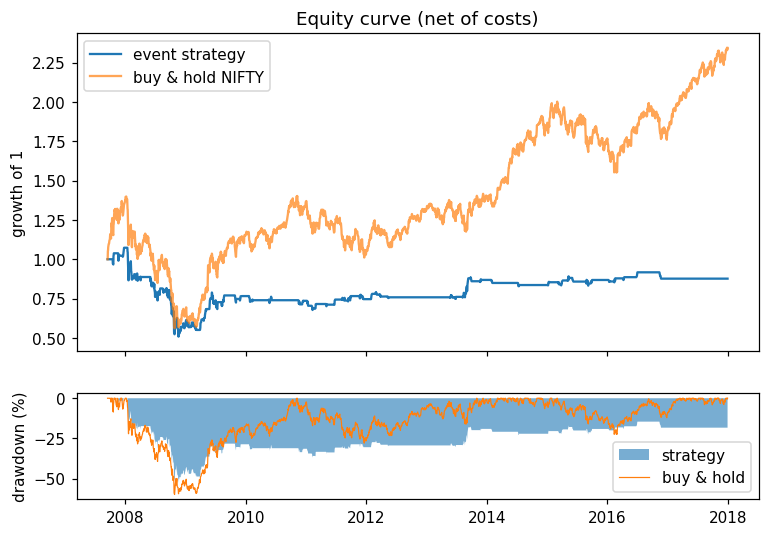

,signal_date,entry_date,exit_date,entry_px,exit_px,bars_held,gross_ret,net_ret,truncated
0,2007-10-18,2007-10-19,2007-10-25,"5,361.95820","5,567.27951",5,0.03892,0.03788,False
1,2007-11-20,2007-11-21,2007-11-27,"5,780.53344","5,696.44046",5,-0.01396,-0.01494,False
2,2007-12-17,2007-12-18,2007-12-26,"5,779.33338","6,068.92878",5,0.05074,0.04969,False
3,2008-01-15,2008-01-16,2008-01-22,"6,066.81950","4,897.83001",5,-0.19220,-0.19301,False
4,2008-01-22,2008-01-23,2008-01-29,"4,904.52072","5,279.21556",5,0.07704,0.07597,False
5,2008-01-30,2008-01-31,2008-02-06,"5,173.80167","5,320.95304",5,0.02906,0.02803,False
6,2008-02-06,2008-02-07,2008-02-13,"5,324.14657","4,927.97136",5,-0.07386,-0.07478,False
7,2008-02-20,2008-02-21,2008-02-27,"5,158.44697","5,266.81938",5,0.02162,0.02060,False
8,2008-03-03,2008-03-04,2008-03-11,"4,960.03737","4,864.44013",5,-0.01868,-0.01967,False
9,2008-03-13,2008-03-14,2008-03-24,"4,625.18694","4,608.46714",5,-0.00302,-0.00401,False


In [10]:
res = EventDrivenBacktester(feat, cfg, end=END_R).run()
print("RESEARCH PERIOD")
display(pd.DataFrame({"strategy": res.metrics, "buy_and_hold": res.benchmark_metrics}))
plot_equity(res); plt.show()
display(res.trades.head(10))

OUT-OF-SAMPLE (frozen parameters)


,strategy,buy_and_hold
total_return,-0.11855,1.24368
cagr,-0.01437,0.09714
ann_vol,0.10062,0.16876
sharpe,-0.09567,0.64668
max_drawdown,-0.35454,-0.38440
max_drawdown_date,2020-03-24 00:00:00,2020-03-23 00:00:00
calmar,-0.04053,0.25269
n_trades,39,NaN
exposure_fraction_of_days,0.07259,NaN
win_rate_net,0.48718,NaN


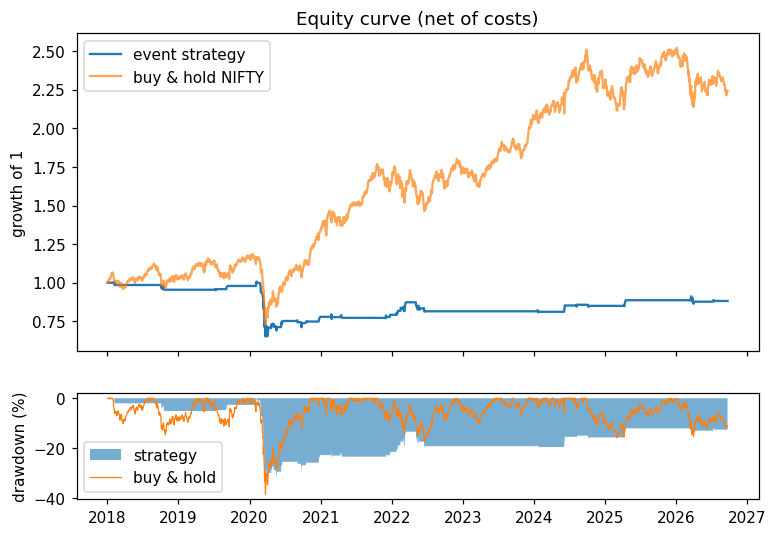

In [11]:
if RUN_OOS:
    res_o = EventDrivenBacktester(feat, cfg, start=cfg.split_date).run()
    print("OUT-OF-SAMPLE (frozen parameters)")
    display(pd.DataFrame({"strategy": res_o.metrics, "buy_and_hold": res_o.benchmark_metrics}))
    plot_equity(res_o); plt.show()

*Reading the backtest.* The strategy is in the market only a few percent of days, so its Sharpe / CAGR are not comparable with buy-and-hold; judge **average net trade, number of trades, profit factor and drawdown** against the research result. This is an *extension* of the research - a backtest that is profitable while the statistical evidence above is not is a warning, not a result.